In [1]:
import pickle
import numpy as np
from astropy.cosmology import Flatw0waCDM
from matplotlib import pyplot as plt
from pdspl_utils.inference import draw_lens_from_given_zs, run_dspl_inference
import corner
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

In [2]:
POSTERIOR_DIRECTORY = './posteriors_split_selection'

## Prepare Datasets for the Forecast

In [3]:
# Load the pdspl_samples object
with open('../data/samples/pdspl_samples_with_pairs.pkl', 'rb') as f:
    pdspl_samples = pickle.load(f)

In [4]:
# --- 1. CONFIGURATION & TRUTH ---
truth = {
    'h0': 70.0, 'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}
fixed_params = {'h0': 70.0}
cosmo_true = Flatw0waCDM(H0=truth['h0'], Om0=truth['om'], w0=truth['w0'], wa=truth['wa'])

In [ ]:
# --- 2. INITIALIZE SCENARIOS ---
dissimilarity_cuts = [0.025, 0.033, 0.05, np.inf] # last one is for the full sample without any cut
colors = ['blue', 'orange', 'red', 'green']

scenarios = {}

org_table = pdspl_samples['lsst_y10']['table']
org_pairs_table = pdspl_samples['lsst_y10']['pairs_analysis']['pairs_table']
org_pairs_table_with_errors = pdspl_samples['lsst_y10']['pairs_analysis']['pairs_table_with_errors']

for i, cut in enumerate(dissimilarity_cuts):
    mask = org_pairs_table_with_errors['dissimilarity'] <= cut
    
    pairs_table_cut = org_pairs_table[mask]
    pairs_table_with_errors_cut = org_pairs_table_with_errors[mask]

    num_pairs_cut = len(pairs_table_cut)
    down_sampling = num_pairs_cut / 2000 if num_pairs_cut > 2000 else 1

    sigma_beta = np.std(1 - pairs_table_cut['beta_E_pseudo']/pairs_table_cut['beta_E_DSPL'])

    key = f'lsst_y10_dissim_leq_{cut:.3f}'
    name = r"PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $"+ f"{cut:.3f})"
    if cut == np.inf:
        name = "LSST Y10 (Full Sample)"
        key = 'lsst_y10_full_sample'


    scenarios[key] = {
        'name': name,
        'down_sampling': down_sampling,
        'num_lenses': num_pairs_cut,
        'color': colors[i],
        'coeffs': pdspl_samples['lsst_y10']['pairs_analysis']['scatter_vs_dissimilarity_fit_coeffs'],
        'pairs_table': pairs_table_cut,
        'pairs_table_with_errors': pairs_table_with_errors_cut,
        'sigma_beta': sigma_beta,
        'redshift_error_rel': 0.03,
        'backend_path': POSTERIOR_DIRECTORY + f"/lsst_y10_dissim_leq_{cut:.3f}.h5"
    }

# --- 3. GENERATE MOCK DATASETS ---
print(f"{'SCENARIO':<60} | {'N_LENS':<10} | {'STATUS'}")
print("-" * 85)

for key in scenarios.keys():
    sc = scenarios[key]
    num_samples = int(sc['num_lenses'] / sc['down_sampling'])
    kwargs_list = []
    
    # Generation from PDSPL tables
    pairs_table = sc['pairs_table']
    pairs_table_with_errors = sc['pairs_table_with_errors']
    coeffs = sc['coeffs']
    random_indices = np.random.choice(len(pairs_table), size=num_samples, replace=False)
    
    for i in random_indices:
        z_lens = pairs_table["z_D"][i]
        z1 = pairs_table["z_S1"][i]
        z2 = pairs_table["z_S2"][i]
        
        dissimilarity = pairs_table_with_errors['dissimilarity'][i]
        rel_scatter_in_beta_E = np.polyval(coeffs, dissimilarity)
        
        sigma_beta_meas, sigma_beta_los = 0.01, 0.01
        rel_scatter_in_beta_E = np.sqrt(rel_scatter_in_beta_E**2 + sigma_beta_meas**2 + sigma_beta_los**2)
        
        kwargs_list.append(draw_lens_from_given_zs(
            z_lens=z_lens, z1=z1, z2=z2,
            lambda_mst_mean=truth['lambda_int'], lambda_mst_sigma=truth['lambda_sigma'],
            gamma_pl_mean=truth['gamma_pl'], gamma_pl_sigma=truth['gamma_sigma'],
            sigma_beta_rel=rel_scatter_in_beta_E, 
            down_sampling=sc['down_sampling'], 
            with_noise=False, # For ASIMOV inference
            cosmo=cosmo_true, 
            redshift_error_rel=sc['redshift_error_rel']
        ))
            
    # Save the generated dataset into the scenario dictionary
    sc['kwargs_list'] = kwargs_list
    print(f"{sc['name']:<60} | {num_samples:<10} | GENERATED")

SCENARIO                                                     | N_LENS     | STATUS
-------------------------------------------------------------------------------------
PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $0.025)   | 1999       | GENERATED
PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $0.033)   | 2000       | GENERATED
PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $0.050)   | 2000       | GENERATED
LSST Y10 (Full Sample)                                       | 1999       | GENERATED


## Run the Forecast Inference

### a. Uniform Prior Forecasts

In [6]:
# --- 1. INFERENCE SETTINGS ---
my_guess = {
    'om': 0.3, 'w0': -1.0, 'wa': 0.0,
    'lambda_int': 1.0, 'lambda_sigma': 0.05,
    'gamma_pl': 2.0, 'gamma_sigma': 0.16
}

my_spreads = {
    'om': 0.1, 'w0': 0.1, 'wa': 0.1,
    'lambda_int': 0.1, 'lambda_sigma': 0.01,
    'gamma_pl': 0.1, 'gamma_sigma': 0.01
}

my_priors = {
    'h0': ('uniform', 50.0, 90.0),
    'om': ('uniform', 0.0, 1.0),
    'w0': ('uniform', -3.0, 0.0),
    'wa': ('uniform', -5.0, 5.0),
    'lambda_int': ('uniform', 0.8, 1.2),
    'lambda_sigma': ('uniform', 0.0, 0.2),
    'gamma_pl': ('uniform', 1.0, 3.0),
    'gamma_sigma': ('uniform', 0.0, 0.5)
}

# --- 2. EXECUTION LOOP ---
print("\n--- Starting MCMC Samplers ---")

param_labels = None 

for key in scenarios.keys():
    sc = scenarios[key]
    
    if 'kwargs_list' not in sc:
        continue # Skip if data wasn't generated
        
    print(f"\nRunning Inference for: {sc['name']}")
    
    samples, labels = run_dspl_inference(
        sc['kwargs_list'],
        n_walkers=64,
        n_steps=2000, 
        n_burn=500,
        initial_guess=my_guess,
        fixed_params=fixed_params,
        initial_scatter=my_spreads,
        priors=my_priors,
        down_sampling=sc['down_sampling'],
        backend_path=sc['backend_path']
    )
    
    sc['samples'] = samples
    param_labels = labels # Saves labels for plotting step
    print(f"{sc['name']} | INFERENCE COMPLETE")


--- Starting MCMC Samplers ---

Running Inference for: PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $0.025)
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 17.036
Saving to     : ./posteriors_split_selection/lsst_y10_dissim_leq_0.025.h5


100%|██████████| 2000/2000 [20:08<00:00,  1.65it/s]


PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $0.025) | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $0.033)
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 24.4815
Saving to     : ./posteriors_split_selection/lsst_y10_dissim_leq_0.033.h5


100%|██████████| 2000/2000 [20:20<00:00,  1.64it/s]


PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $0.033) | INFERENCE COMPLETE

Running Inference for: PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $0.050)
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 32.478
Saving to     : ./posteriors_split_selection/lsst_y10_dissim_leq_0.050.h5


100%|██████████| 2000/2000 [18:39<00:00,  1.79it/s]


PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $0.050) | INFERENCE COMPLETE

Running Inference for: LSST Y10 (Full Sample)
--- Starting DSPL Inference ---
Fixed Params  : ['h0']
Sampled Params: ['om', 'w0', 'wa', 'lambda_int', 'lambda_sigma', 'gamma_pl', 'gamma_sigma']
Down Sampling : 42.968
Saving to     : ./posteriors_split_selection/lsst_y10_dissim_leq_inf.h5


100%|██████████| 2000/2000 [20:00<00:00,  1.67it/s]

LSST Y10 (Full Sample) | INFERENCE COMPLETE


## Plotting the Forecast Results

In [7]:
def plot_dspl_corner(scenarios, truth, fixed_params, scenarios_to_plot=None, 
                     custom_ranges=None, latex_labels=None, figsize=(12, 12),
                     show_multiple_titles=True, error_type='asymmetric',
                     title_y_spacing=0.15, samples_key='samples', 
                     custom_colors_dict=None):
    """
    Generates a combined corner plot for multiple MCMC scenarios with custom stacked titles.
    
    Parameters:
        scenarios (dict): Dictionary containing scenario data (samples, color, name, etc.).
        truth (dict): Dictionary of true parameter values.
        fixed_params (dict): Dictionary of fixed parameters to exclude from plotting.
        scenarios_to_plot (list): Keys of scenarios to plot. Defaults to all keys in scenarios.
        custom_ranges (list of tuples): Plot ranges for each parameter.
        latex_labels (dict): Mapping of parameter keys to LaTeX strings.
        figsize (tuple): Size of the resulting figure.
        show_multiple_titles (bool): If True, stacks colored titles on diagonal axes.
        error_type (str): 'asymmetric' (median +upper/-lower) or 'symmetric' (mean +/- std).
        title_y_spacing (float): Vertical spacing multiplier for stacking titles.
    
    Returns:
        fig: The generated matplotlib Figure object.
    """
    # 1. Setup Data and Labels
    if scenarios_to_plot is None:
        scenarios_to_plot = list(scenarios.keys())

    sampled_keys = [k for k in truth.keys() if k not in fixed_params]
    truth_values = [truth[k] for k in sampled_keys]
    
    if latex_labels is None:
        latex_labels = {k: k for k in sampled_keys}
    plot_labels = [latex_labels.get(k, k) for k in sampled_keys]

    fig = plt.figure(figsize=figsize)

    # Filter out scenarios that haven't been run yet
    valid_scenarios = [key for key in scenarios_to_plot if key in scenarios and 'samples' in scenarios[key]]

    colors_for_valid_scenarios = [scenarios[key]['color'] if custom_colors_dict is None else custom_colors_dict.get(key, scenarios[key]['color']) for key in valid_scenarios]

    # 2. Draw Contours
    for key in valid_scenarios:
        sc = scenarios[key]
        
        fig = corner.corner(
            sc[samples_key],
            fig=fig,
            labels=plot_labels,
            range=custom_ranges,
            color=colors_for_valid_scenarios[valid_scenarios.index(key)],
            weights=np.ones(len(sc[samples_key])) / len(sc[samples_key]),
            smooth=2,
            
            plot_datapoints=False,  
            plot_density=False,     
            fill_contours=True,    
            show_titles=False,      # Disabled so we can manually add multiple titles
            
            levels=[0.68, 0.95],    
            hist_kwargs={"density": True, "linewidth": 2, "histtype": "step"},
            contour_kwargs={"linewidths": 2},
            
            truths=truth_values, 
            truth_color="#444444",
            label_kwargs={"fontsize": 14}
        )

    # 3. Stacked Colored Titles
    if show_multiple_titles and valid_scenarios:
        ndim = len(sampled_keys)
        # Corner creates a flat list of axes; reshape to an N x N grid
        axes = np.array(fig.axes).reshape((ndim, ndim))
        
        for col_idx, param_key in enumerate(sampled_keys):
            # Extract the 1D histogram axis on the diagonal
            ax = axes[col_idx, col_idx] 
            
            # Get the latex label and strip existing $ signs for clean formatting
            param_label_raw = plot_labels[col_idx]
            param_math_text = param_label_raw.replace('$', '')
            
            for row_idx, sc_key in enumerate(valid_scenarios):
                sc = scenarios[sc_key]
                
                # Extract the 1D array of samples for this specific parameter
                samples_1d = sc['samples'][:, col_idx]
                
                if error_type == 'symmetric':
                    # Mean and Standard Deviation
                    mean_val = np.mean(samples_1d)
                    std_val = np.std(samples_1d)
                    title_str = fr"${param_math_text} = {mean_val:.2f} \pm {std_val:.2f}$"
                else:
                    # Asymmetric (Median and 16th/84th percentiles)
                    q16, q50, q84 = np.percentile(samples_1d, [16, 50, 84])
                    lower_err = q50 - q16
                    upper_err = q84 - q50
                    title_str = fr"${param_math_text} = {q50:.2f}^{{+{upper_err:.2f}}}_{{-{lower_err:.2f}}}$"
                
                # Calculate vertical offset so text lines stack upward
                y_offset = 1.05 + (title_y_spacing * row_idx) 
                
                ax.text(0.5, y_offset, title_str, transform=ax.transAxes, 
                        ha='center', va='bottom', color=colors_for_valid_scenarios[valid_scenarios.index(sc_key)], fontsize=11)

    # 4. Custom Legend
    legend_handles = []
    for key in valid_scenarios:
        sc = scenarios[key]
        line = mlines.Line2D([], [], color=colors_for_valid_scenarios[valid_scenarios.index(key)], linewidth=3, 
                             label=f"{sc['name']}"# (N={sc['num_lenses']})"
                             )
        legend_handles.append(line)

    fig.legend(
        handles=legend_handles,
        loc='upper right',
        bbox_to_anchor=(0.98, 0.98), 
        bbox_transform=fig.transFigure,
        fontsize=14,
        frameon=False
    )

    return fig

In [8]:
latex_labels = {
    'om': r"$\Omega_{\rm m}$", 'w0': r"$w_0$", 'wa': r"$w_a$", 
    'lambda_int': r"$\overline{\lambda}_{\rm int}$", 
    'gamma_pl': r"$\overline{\gamma}_{\rm pl}$", 
    'gamma_sigma': r"$\sigma({\gamma}_{\rm pl})$", 
    'lambda_sigma': r"$\sigma({\lambda}_{\rm int})$"
}

custom_ranges = [
    (0, 1),           # om
    (-2, 0),          # w0
    (-3, 3),          # wa
    (truth['lambda_int'] - 0.1, truth['lambda_int'] + 0.1), # lambda_int
    (0.0, 0.10),      # lambda_sigma
    (truth['gamma_pl'] - 0.1, truth['gamma_pl'] + 0.1), # gamma_pl
    (0.12, 0.20),     # gamma_sigma
]

###  a. All Scenarios Corner Plot -- Uniform Priors

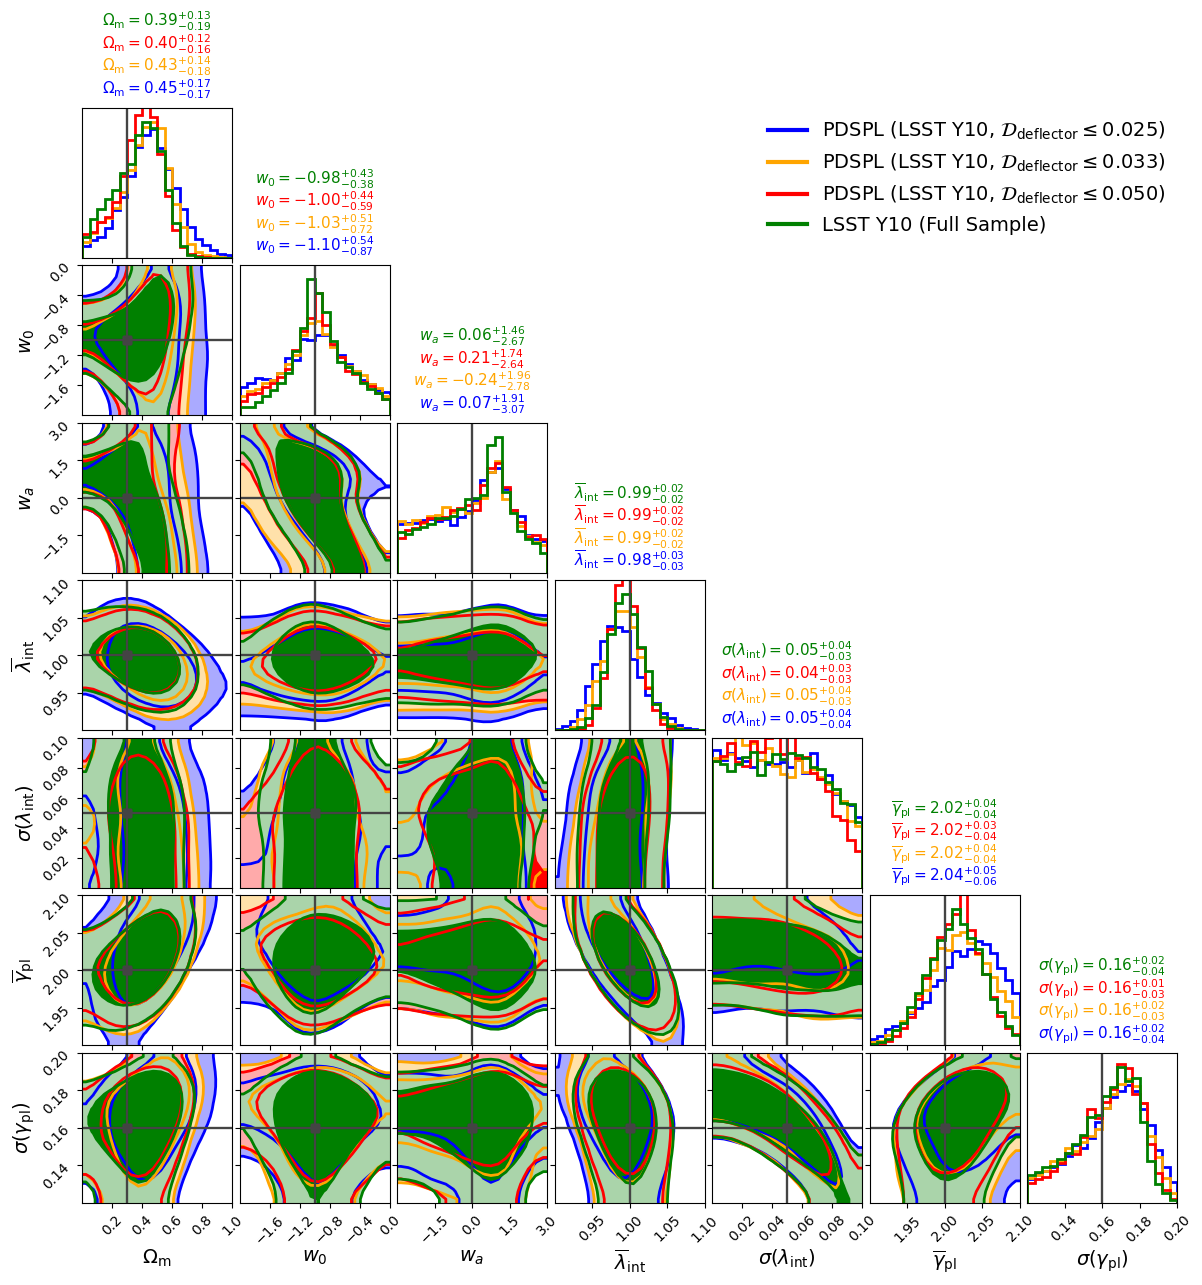

In [68]:

scenarios_to_plot = [
    'lsst_y10_dissim_leq_0.025',
    'lsst_y10_dissim_leq_0.033',
    'lsst_y10_dissim_leq_0.050',
    'lsst_y10_full_sample'
]

fig = plot_dspl_corner(
    scenarios=scenarios, 
    truth=truth, 
    fixed_params=fixed_params, 
    scenarios_to_plot=scenarios_to_plot,
    custom_ranges=custom_ranges,
    latex_labels=latex_labels,
    figsize=(12, 12),
    show_multiple_titles=True
)

plt.show()

fig.savefig("./figures/forecast_w0waCDM_scatter_LSST_Y10_dissimilarity_cuts.png")

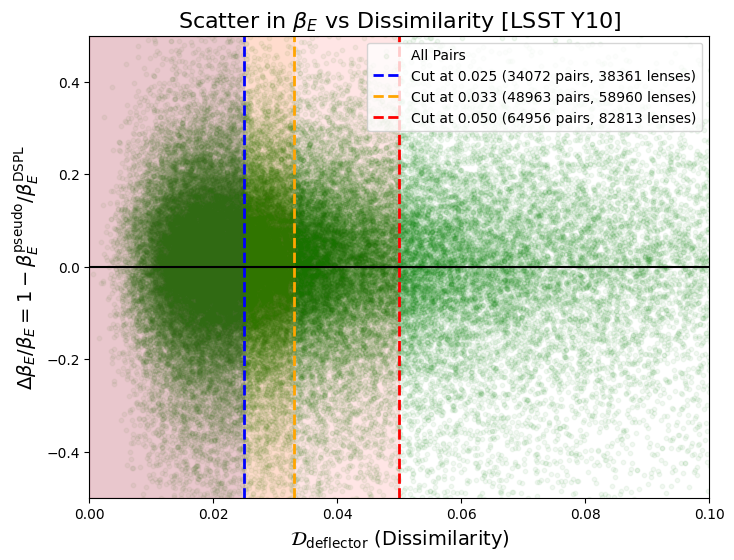

In [65]:
# plot the scatter in beta_E vs dissimilarity and make vertical lines for the cuts
plt.figure(figsize=(8, 6))
plt.scatter(org_pairs_table_with_errors['dissimilarity'], 
            1 - org_pairs_table['beta_E_pseudo']/org_pairs_table['beta_E_DSPL'], 
            alpha=0.05, label='All Pairs', s=10, color='green')

for i, cut in enumerate(dissimilarity_cuts[:-1]):  # Skip the last cut since it's infinity
    filtered_pairs = org_pairs_table_with_errors[org_pairs_table_with_errors['dissimilarity'] > cut]
    indices_1 = filtered_pairs['index_1']
    indices_2 = filtered_pairs['index_2']
    unique_indices = np.unique(np.concatenate([indices_1, indices_2]))
    
    n_pairs = len(org_pairs_table_with_errors) - len(filtered_pairs)
    n_lenses = len(org_table) - len(unique_indices)
    
    # Update the label to include the object count
    plt.axvline(cut, color=colors[i], linestyle='--', 
                label=f'Cut at {cut:.3f} ({n_pairs} pairs, {n_lenses} lenses)', linewidth=2)
    
    # Shade the region from 0 to the current cut
    plt.axvspan(0, cut, color=colors[i], alpha=0.1)

plt.axhline(0, color='black', linestyle='-')

plt.xlabel('$\\mathcal{D}_{\\rm deflector}$ (Dissimilarity)', fontsize=14)
plt.ylabel(r'$\Delta\beta_E/\beta_E = 1 - \beta_E^{\rm pseudo} / \beta_E^{\rm DSPL}$', fontsize=14)
plt.title('Scatter in $\\beta_E$ vs Dissimilarity [LSST Y10]', fontsize=16)
plt.xlim(0, 0.1)
plt.ylim(-0.5, 0.5)
plt.legend()
plt.show()

fig.savefig("./figures/scatter_in_beta_E_vs_dissimilarity.png")

In [63]:
cut = 0.05

filtered_pairs_below_cut = org_pairs_table_with_errors[org_pairs_table_with_errors['dissimilarity'] <= cut]
filtered_pairs_above_cut = org_pairs_table_with_errors[org_pairs_table_with_errors['dissimilarity'] > cut]

unique_indices_below = np.unique(np.concatenate([filtered_pairs_below_cut['index_1'], filtered_pairs_below_cut['index_2']]))
unique_indices_above = np.unique(np.concatenate([filtered_pairs_above_cut['index_1'], filtered_pairs_above_cut['index_2']]))

print(f"Number of pairs below cut: {len(filtered_pairs_below_cut)}")
print(f"Number of pairs above cut: {len(filtered_pairs_above_cut)}")
print(f"Number of unique lenses below cut: {len(unique_indices_below)}")
print(f"Number of unique lenses above cut: {len(unique_indices_above)}")

Number of pairs below cut: 64956
Number of pairs above cut: 20980
Number of unique lenses below cut: 92505
Number of unique lenses above cut: 33658


## Table of All Forecast Results

In [14]:
# print a latex table of the median and 16th/84th percentiles for each parameter and scenario
print("\n--- Parameter Summary Table (Median with 16th/84th Percentiles) ---")
print(f"{'Scenario':<80} | {'Parameter':<30} | {'Median':<10} | {'-1σ':<10} | {'+1σ':<10}")
print("-" * 150) 
for key in scenarios.keys():
    sc = scenarios[key]
    if 'samples' not in sc:
        continue
    
    samples = sc['samples']
    scenario_name = sc['name']
    
    for param_idx, param_key in enumerate(param_labels):
        samples_1d = samples[:, param_idx]
        q16, q50, q84 = np.percentile(samples_1d, [16, 50, 84])
        lower_err = q50 - q16
        upper_err = q84 - q50
        
        print(f"{scenario_name:<80} | {param_key:<30} | {q50:<10.3f} | {lower_err:<10.3f} | {upper_err:<10.3f}")


--- Parameter Summary Table (Median with 16th/84th Percentiles) ---
Scenario                                                                         | Parameter                      | Median     | -1σ        | +1σ       
------------------------------------------------------------------------------------------------------------------------------------------------------
PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $0.025)                       | $\Omega_m$                     | 0.454      | 0.171      | 0.167     
PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $0.025)                       | $w_0$                          | -1.099     | 0.869      | 0.543     
PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $0.025)                       | $w_a$                          | 0.066      | 3.074      | 1.912     
PDSPL (LSST Y10, $\mathcal{D}_{\rm deflector} \leq $0.025)                       | $\bar{\lambda}_{int}$          | 0.984      | 0.027      | 0.031     
PDSPL (LSST Y10

In [ ]:
# save the scenarios dictionary with the samples included into a new pickle file for later use
# with open('./forecast_scenarios_PDSPL_splits_w0waCDM_scatter_custom.pkl', 'wb') as f:
#     pickle.dump(scenarios, f)